[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03a_baseline.ipynb)

# 03a — Baseline Experiment: Random Search and a Rule-Based Sweep

## 1. Overview

This notebook evaluates two **baseline optimization methods** for multi-band antenna tilt coordination: choosing one
tilt per `(cell, band)` pair to improve coverage while limiting co-band overlap. The baselines are
the reference TuRBO (notebook 03b) is read against.

**Goals.**

- Run two simple, reproducible baselines on the same simulator, scenario and objective as TuRBO.
- Measure what they change on every KPI, and where on the map.
- Set the reference performance level for the method comparison in notebook 04.

The problem formulation (the tilt vector and its bounds) and the KPI definitions are described in notebook 01
(sections 2, 7, 8 and 12) and are not repeated here.

**Outputs.** One run directory per method and seed under `outputs/optim/`, tables under
`reports/tables/03a_baseline/`, figures under `reports/figures/03a_baseline/`. **Requirements.** A CUDA GPU.
The shell equivalent of the runs is `task baseline` (random search) and `task baseline -- optim/method=rule`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.config import load_config
from src.evaluation import compare, maps, plots
from src.evaluation import runs as run_store
from src.evaluation.export import readable, save_table
from src.kpi.capacity import CapacitySpec, max_rsrp
from src.kpi.overlap import overlap_neighbors
from src.optim.objective import MAXIMISED
from src.optim.run import run
from src.optim.space import TiltSpace
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03a_baseline"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03a_baseline"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

# Search seeds: optim.seed from the config; BAND_TILT_SEEDS (space-separated) overrides it.
SEEDS = [int(seed) for seed in os.environ.get("BAND_TILT_SEEDS", str(cfg.optim.seed)).split()]
METHODS = ("random", "rule")

## 2. Baseline Methods

### Random search (`optim/method=random`)

Scrambled Sobol points drawn uniformly over the tilt box, each ray-traced and scored; the configuration with the
highest objective is kept. It is matched to TuRBO on the evaluation budget and seed, and its first `n_init` points
are TuRBO's initial design, so any gap between the two is what the model contributes.

### Rule-based sweep (`optim/method=rule`)

The operator heuristic: every cell on a band shares one tilt, and the band tilts are tuned by coordinate descent,
trying `n_steps` values per band per pass over `n_rounds` passes. It is deterministic and not budget-matched.

### Why these baselines?

- Neither needs a learned model.
- Both are straightforward to reproduce from a seed and a config.
- Random search makes no assumption about the objective landscape; the sweep encodes the one an operator would make.
- Together they bound what TuRBO has to beat: an unstructured search at equal budget and a structured one at far
  lower cost.

## 3. Experimental Setup

Every value below is read from the composed config and the simulation output, not restated by hand.

In [3]:
space = TiltSpace.from_config(cfg)
baseline = run_store.baseline_map(cfg)
cells = pd.read_parquet(cfg.data.output.cell_file).drop_duplicates("cell")
ue = pd.read_parquet(cfg.data.output.ue_file)
radio_cfg = cfg.simulation.radio_map
n_rows, n_cols = maps.grid_shape(baseline)

network = pd.DataFrame(
    {
        "Parameter": [
            "Sites (nodes)",
            "Cells",
            "Frequency bands",
            "Optimized variables",
            "Tilt range [°]",
            "Current tilt [°]",
            "Tilt step, maximum tilt change",
        ],
        "Value": [
            cells["node"].nunique(),
            len(space.cells),
            ", ".join(label(band) for band in space.band_names),
            f"{space.n_dim} ({len(space.cells)} cells x {len(space.band_names)} bands)",
            f"{space.lower.min():g} – {space.upper.max():g}",
            ", ".join(f"{value:g}" for value in np.unique(space.baseline)),
            "Not constrained: continuous tilt inside the box",
        ],
    }
)
mechanisms = [
    name
    for name in ("los", "specular_reflection", "diffuse_reflection", "refraction", "diffraction")
    if bool(radio_cfg[name])
]
simulation = pd.DataFrame(
    {
        "Parameter": [
            "Simulator",
            "Scene",
            "Scenario",
            "Grid resolution [m]",
            "Evaluation tiles",
            "Rays per transmitter",
            "Maximum path depth",
            "Propagation mechanisms",
        ],
        "Value": [
            "Sionna RT",
            str(cfg.simulation.scene.name),
            str(baseline["scenario_id"]),
            f"{float(baseline['tile_size_m']):g}",
            f"{n_rows * n_cols} ({n_rows} x {n_cols})",
            f"{int(radio_cfg.samples_per_tx):,}",
            int(radio_cfg.max_depth),
            ", ".join(mechanisms),
        ],
    }
)
users = pd.DataFrame(
    {
        "Parameter": ["UE reports", "Intervals", "Distribution"],
        "Value": [
            len(ue),
            ue["t_index"].nunique(),
            "Uniform open-ground background plus Gaussian hotspots (notebook 00)",
        ],
    }
)
for name, table in (("network", network), ("simulation", simulation), ("users", users)):
    save_table(table, f"setup_{name}")
    display(table)

,Parameter,Value
0,Sites (nodes),4
1,Cells,12
2,Frequency bands,"2600 MHz, 1800 MHz, 700 MHz"
3,Optimized variables,36 (12 cells x 3 bands)
4,Tilt range [°],0 – 15
5,Current tilt [°],"8, 10, 12"
6,"Tilt step, maximum tilt change",Not constrained: continuous tilt inside the box


,Parameter,Value
0,Simulator,Sionna RT
1,Scene,data/external/scene/scene.xml
2,Scenario,scn_7d938e15f9ac4618
3,Grid resolution [m],20
4,Evaluation tiles,101060 (326 x 310)
5,Rays per transmitter,"10,000,000"
6,Maximum path depth,8
7,Propagation mechanisms,"los, specular_reflection, refraction"


,Parameter,Value
0,UE reports,10087
1,Intervals,672
2,Distribution,Uniform open-ground background plus Gaussian h...


Every candidate is scored on all UEs, so the numbers from section 6 onwards are the search's own measurements.

## 4. Baseline Configuration

Both methods start from the committed network configuration, which is always evaluation 0 of a run.

In [4]:
def method_config(method):
    return load_config(overrides=[f"optim/method={method}", *CONFIG_OVERRIDES]).optim


random_cfg, rule_cfg = method_config("random"), method_config("rule")
n_band = len(space.band_names)
budgets = pd.DataFrame(
    {
        "Parameter": [
            "Search strategy",
            "Evaluations (excluding the incumbent)",
            "Budget split",
            "Search seeds",
            "Initial configuration",
            "Solutions published",
        ],
        label("random"): [
            "Scrambled Sobol sampling over the tilt box",
            int(random_cfg.method.budget.n_init) + int(random_cfg.method.budget.n_iter),
            f"n_init={random_cfg.method.budget.n_init}, n_iter={random_cfg.method.budget.n_iter}",
            ", ".join(map(str, SEEDS)),
            "Current network",
            int(random_cfg.n_solutions),
        ],
        label("rule"): [
            "One tilt per band, coordinate descent",
            f"at most {n_band * int(rule_cfg.method.n_steps) * int(rule_cfg.method.n_rounds)}",
            f"n_steps={rule_cfg.method.n_steps}, n_rounds={rule_cfg.method.n_rounds}",
            "Deterministic",
            "Current network",
            int(rule_cfg.n_solutions),
        ],
    }
)
save_table(budgets, "baseline_configuration")
budgets

,Parameter,Random search,Rule-based sweep
0,Search strategy,Scrambled Sobol sampling over the tilt box,"One tilt per band, coordinate descent"
1,Evaluations (excluding the incumbent),144,at most 30
2,Budget split,"n_init=16, n_iter=128","n_steps=5, n_rounds=2"
3,Search seeds,42,Deterministic
4,Initial configuration,Current network,Current network
5,Solutions published,4,4


## 5. Runs

Each run evaluates the current configuration first, then searches, then re-traces its winner once to archive its
radio map. A run already on disk for the same method and seed is reused; delete its directory under `outputs/optim/` to
repeat it. The runs are then checked comparable with the current radio map: same scenario, grid, solver settings,
bands and KPI definition.

In [5]:
def on_disk():
    # The newest finished run of each method and seed.
    return run_store.latest_per_method_and_seed(run_store.discover(cfg.optim.output.dir))


done = {(r.method, r.seed) for r in on_disk()}
for seed in SEEDS:
    if ("random", seed) not in done:
        run(load_config(overrides=["optim/method=random", f"optim.seed={seed}", *CONFIG_OVERRIDES]))

# Deterministic, so one run; its seed only labels it.
if not any(method == "rule" for method, _ in done):
    run(load_config(overrides=["optim/method=rule", f"optim.seed={SEEDS[0]}", *CONFIG_OVERRIDES]))

runs = [r for r in on_disk() if r.method == "rule" or (r.method == "random" and r.seed in SEEDS)]
checks = run_store.verify(runs, baseline)
run_store.require(checks)
print(f"{len(runs)} runs; {int(checks['holds'].sum())} of {len(checks)} comparability checks hold")
# Each method's best run over its seeds, for the per-method sections below.
best = compare.best_run_per_method(runs)

2 runs; 23 of 23 comparability checks hold


## 6. Initial Network State

The committed configuration, scored on every UE. Mean overlapping neighbours (co-band cells within the overlap margin
of the serving cell, summed over bands, averaged over covered tiles) is a diagnostic computed from the radio map; no
score reads it.

In [6]:
def mean_overlap_neighbors(rsrp):
    covered = max_rsrp(rsrp) > float(cfg.kpi.hole_dbm)
    return float(overlap_neighbors(rsrp, cfg)[covered].mean())


incumbent = runs[0].incumbent_kpi
baseline_rsrp = baseline["rsrp_dbm"].astype(float)
initial = pd.DataFrame(
    {
        "kpi": [*incumbent.as_dict(), "Mean overlapping neighbours"],
        "direction": [compare.direction(name) for name in incumbent.as_dict()] + ["minimise"],
        "value": [
            *incumbent.as_dict().values(),
            mean_overlap_neighbors(baseline_rsrp),
        ],
    }
)
initial = readable(initial.rename(columns={"value": "Initial value"}))
save_table(initial, "initial_state")
initial

,KPI,Direction,Initial value
0,Coverage hole rate,minimise,0.1125
1,Co-band overlap rate,minimise,0.3164
2,Overlap neighbours per covered tile,minimise,0.9625
3,Weak coverage rate,minimise,0.3069
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644
5,"Median RSRP, p50 [dBm]",maximise,-84.1068
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729
7,"Median SINR, p50 [dB]",maximise,8.4932
8,Served UE rate,maximise,0.5265
9,Peak PRB utilisation,minimise,0.7999


## 7. Optimization Process and Objective

Every candidate goes through the same loop, and every KPI is a measurement: nothing is predicted by a surrogate.

```text
Current tilt configuration (evaluation 0)
        │
        ▼
Generate candidate tilt ── random: Sobol point · rule: one band's shared tilt
        │
        ▼
Apply constraints ──────── clip to [tilt_min, tilt_max] per cell-band
        │
        ▼
Radio simulation ───────── Sionna RT, one solve per band
        │
        ▼
Compute KPIs and J ─────── src/optim/objective.py
        │
        ▼
Keep best configuration ── highest J; a tie keeps the earlier evaluation
```

Both methods maximise the project objective (ADR 0007, `configs/kpi.yaml` `objective`):

$$
J = \sum_{b \in B} \sum_{g \in G} w_{bg}\,
\sigma\!\left(\frac{R_{sb}(g) - T_\text{cov}}{\tau_R}\right) e^{-\beta\, m_{bg}},
\qquad
w_{bg} = \frac{1 - \alpha_b}{|G|} + \alpha_b\, p_g
$$

One term per band, summed. $R_{sb}(g)$ is the strongest transmitter **on band
$b$** at tile $g$ and $m_{bg}$ its count of overlapping co-band neighbours, so a
hole on one layer is not hidden by another layer covering it. $p_g$ is the
demand map's tile share (MDT reports per tile, normalised) and $\alpha_b$ is that
band's `kpi.objective.alpha`: 0 weights the map evenly, as a coverage layer
wants, and 1 weights only where the traffic was measured, as a capacity layer
wants.

Each band's weights sum to one, so $J \in [0, |B|]$ — **not** $[0, 1]$;
**higher is better**. The KPIs are reported beside it, tile-uniform and
band-collapsed; none of them is weighted into it.

In [7]:
objective = cfg.kpi.objective
parameters = pd.DataFrame(
    {
        "Parameter": ["T_cov [dBm]", "Delta_R [dB]", "tau_R [dB]", "beta"]
        + [f"alpha, {band}" for band in objective.alpha],
        "Value": [
            cfg.kpi.hole_dbm,
            cfg.kpi.overlap_margin_db,
            objective.tau_r_db,
            objective.beta,
        ]
        + [float(value) for value in objective.alpha.values()],
    }
)
save_table(parameters, "objective_parameters")
parameters

,Parameter,Value
0,T_cov [dBm],-120.00
1,Delta_R [dB],6.00
2,tau_R [dB],17.00
3,beta,0.25
4,"alpha, b2600",1.00
5,"alpha, b1800",0.50
6,"alpha, b700",0.00


## 8. Optimization Progress

Best value found so far per evaluation, from the search history. Random search is shown as the mean over seeds with
the min–max band.

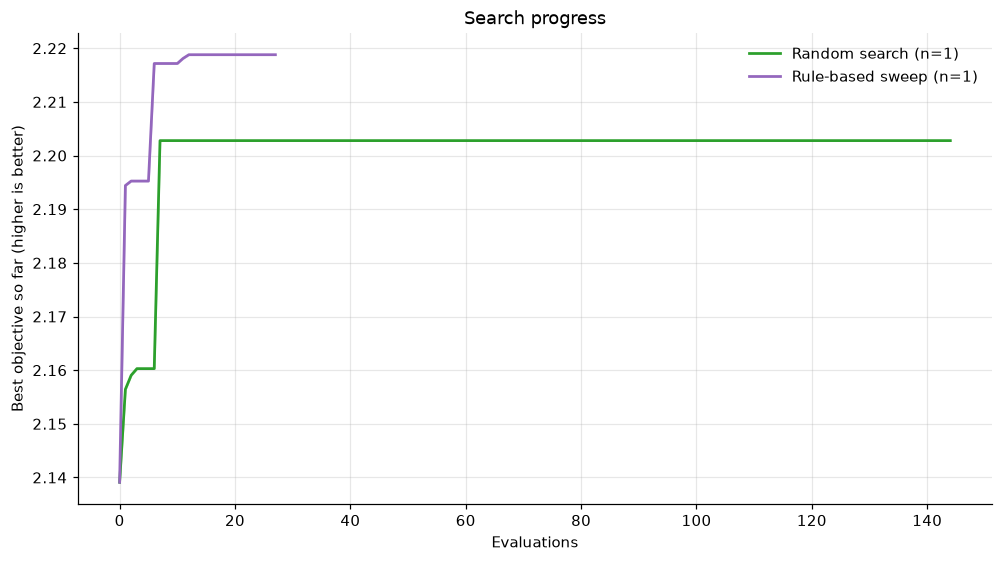

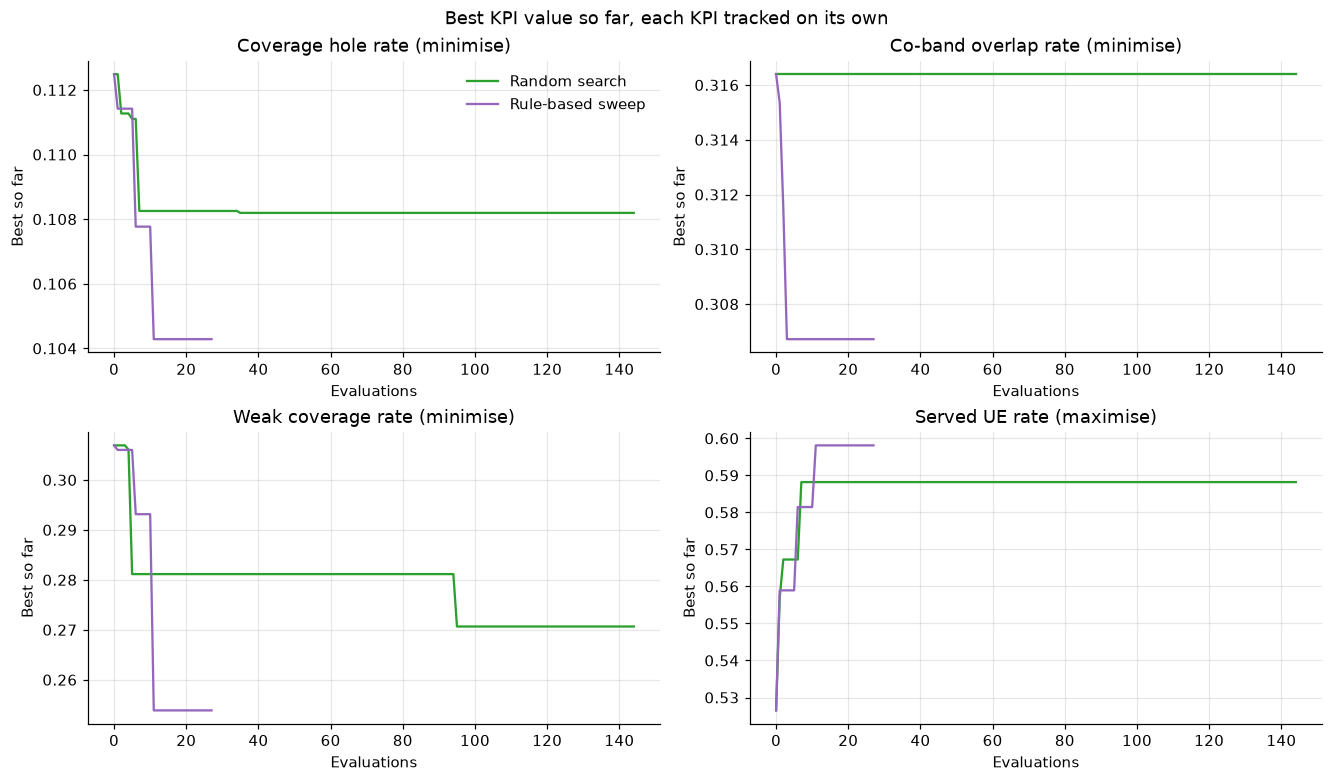

In [8]:
trace = compare.convergence(runs)
figure = plots.convergence_plot(trace)
save_fig(figure, "search_progress")
plt.show()

figure, axes = plt.subplots(2, 2, figsize=(12.0, 7.0), constrained_layout=True)
for axis, name in zip(axes.ravel(), ("hole_rate", "overlap_rate", "weak_rate", "served_rate"), strict=True):
    part = trace[trace["kpi"] == name]
    for method, group in part.groupby("method", sort=False):
        mean = group.groupby("iteration")["value"].mean()
        axis.plot(mean.index, mean.to_numpy(), color=plots.COLOURS.get(method), label=label(method))
    axis.set_title(f"{label(name)} ({compare.direction(name)})")
    axis.set_xlabel("Evaluations")
    axis.set_ylabel("Best so far")
axes[0, 0].legend()
figure.suptitle("Best KPI value so far, each KPI tracked on its own")
save_fig(figure, "kpi_progress")
plt.show()

Each KPI panel tracks that KPI's own best value, which need not come from the configuration with the best J.

**Observations.** Random search found its best configuration at evaluation 7, inside the Sobol initial design, and
none of the later 137 draws beat it; its best J is 2.2028 against the current configuration's 2.1391. The rule-based
sweep's first pass over the three bands supplies nearly its whole gain (2.2172 after 10 evaluations), and it ends at
2.2188 after 28 evaluations - above random search at a seventh of the ray-tracing cost. $J$ is a per-band sum now
(ADR 0007), so it runs in $[0, 3]$ and these values do not compare with anything recorded before that change.

## 9. Best Tilt Configuration

The deliverable of each method's best run: current and proposed tilt per cell-band. Negative change is uptilt.

Random search: run 2026-09-19_04-01-54, seed 42, best evaluation 7


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,4.9663,9.3717,-3.8540
1,2600 MHz,12,12,6.7463,11.5816,-6.7463
2,700 MHz,12,12,3.7455,6.9661,-2.6057


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,6.0149,-5.9851,0.0,15.0
1,n0c0,1800 MHz,10.0,2.7582,-7.2418,0.0,15.0
2,n0c0,700 MHz,8.0,7.3027,-0.6973,0.0,15.0
3,n0c1,2600 MHz,12.0,11.1984,-0.8016,0.0,15.0
4,n0c1,1800 MHz,10.0,2.0915,-7.9085,0.0,15.0
5,n0c1,700 MHz,8.0,11.0507,3.0507,0.0,15.0
6,n0c2,2600 MHz,12.0,4.5229,-7.4771,0.0,15.0
7,n0c2,1800 MHz,10.0,8.1376,-1.8624,0.0,15.0
8,n0c2,700 MHz,8.0,1.7780,-6.2220,0.0,15.0
9,n1c0,2600 MHz,12.0,11.8575,-0.1425,0.0,15.0


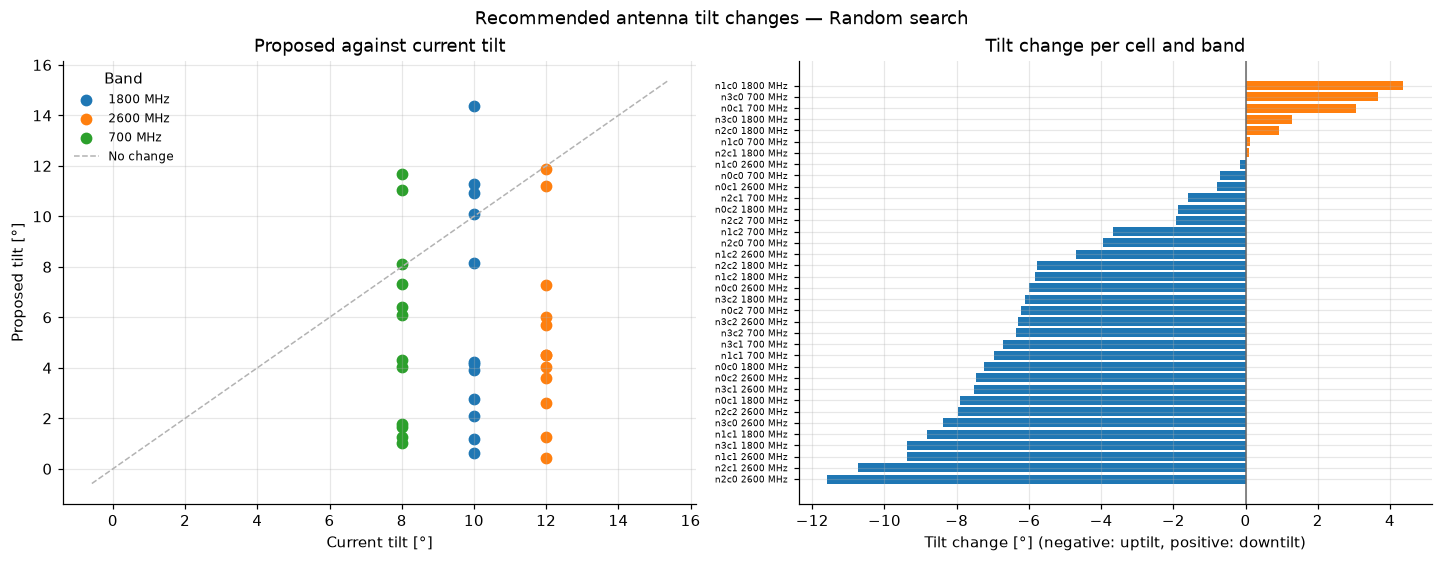

Rule-based sweep: run 2026-09-19_04-09-16, seed 42, best evaluation 12


,Band,Cells,Cells moved,Mean absolute tilt change [°],Largest tilt change [°],Mean tilt change [°]
0,1800 MHz,12,12,10.00,10.00,-10.00
1,2600 MHz,12,12,8.25,8.25,-8.25
2,700 MHz,12,12,4.25,4.25,-4.25


,Cell,Band,Current tilt [°],Proposed tilt [°],Tilt change [°],Minimum tilt [°],Maximum tilt [°]
0,n0c0,2600 MHz,12.0,3.75,-8.25,0.0,15.0
1,n0c0,1800 MHz,10.0,0.00,-10.00,0.0,15.0
2,n0c0,700 MHz,8.0,3.75,-4.25,0.0,15.0
3,n0c1,2600 MHz,12.0,3.75,-8.25,0.0,15.0
4,n0c1,1800 MHz,10.0,0.00,-10.00,0.0,15.0
5,n0c1,700 MHz,8.0,3.75,-4.25,0.0,15.0
6,n0c2,2600 MHz,12.0,3.75,-8.25,0.0,15.0
7,n0c2,1800 MHz,10.0,0.00,-10.00,0.0,15.0
8,n0c2,700 MHz,8.0,3.75,-4.25,0.0,15.0
9,n1c0,2600 MHz,12.0,3.75,-8.25,0.0,15.0


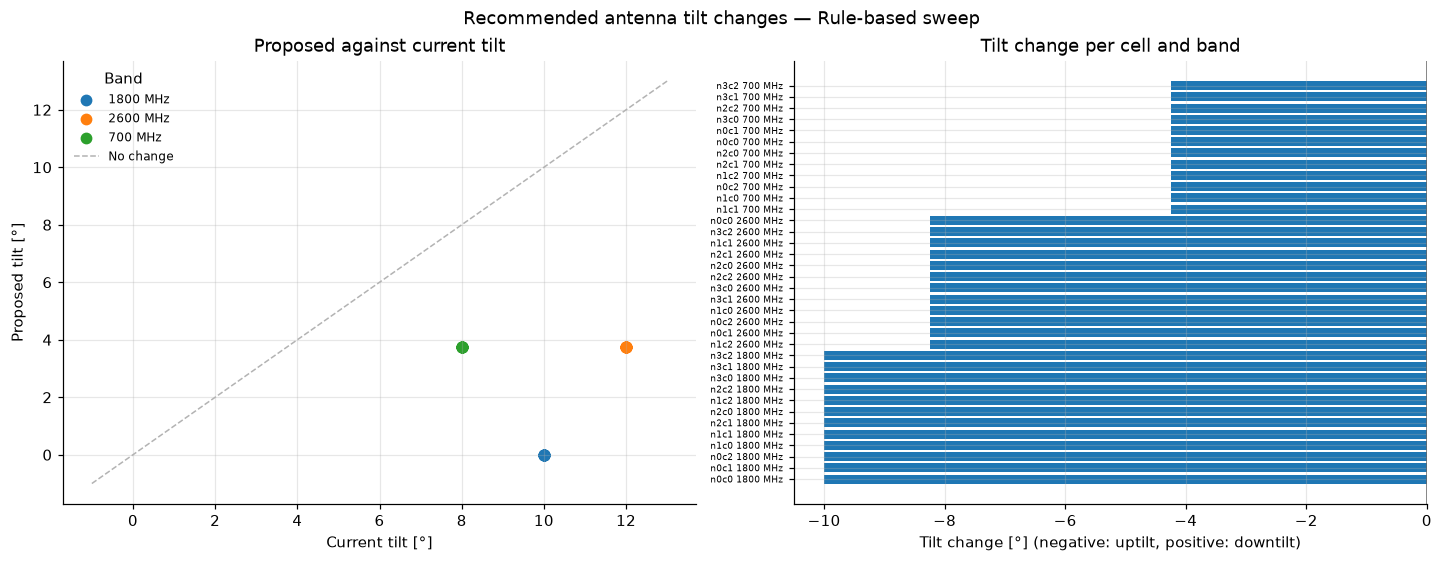

In [9]:
for method in METHODS:
    chosen = best[method]
    tilt = readable(chosen.best_tilt)
    save_table(tilt, f"best_tilt_{method}")
    summary = readable(compare.tilt_movement(chosen))
    save_table(summary, f"tilt_movement_{method}")
    print(f"{label(method)}: run {chosen.run_id}, seed {chosen.seed}, best evaluation {chosen.best_index}")
    display(summary)
    display(tilt)
    figure = plots.tilt_movement_plot(chosen.best_tilt, method)
    save_fig(figure, f"tilt_movement_{method}")
    plt.show()

**Observations.** The sweep sets every cell to 3.75° on 2600 MHz and 700 MHz and 0° on 1800 MHz: 8.25° of uptilt
on the high band, 10° on the mid and 4.25° on the low, applied identically to all twelve cells, since it can only move
bands as a whole. The mid band ends pinned at the bottom of its tilt box, so the sweep would take it further if the
bounds allowed. Random search's best point uptilts every band on average too - to 5.3° on 2600 MHz, 6.2° on 1800 MHz
and 5.4° on 700 MHz - but by amounts that vary from 0.4° to 14.4° with no visible pattern by node. That spread is what
one Sobol draw looks like, not evidence that those cells need different tilts.

## 10. Final Results

### KPI comparison

Each method's best configuration against the current one, on every UE. Relative improvement is signed so that
positive is better whichever direction the KPI runs:

$$
\text{Improvement} = s \cdot \frac{KPI_\text{optimized} - KPI_\text{initial}}{|KPI_\text{initial}|} \times 100\%,
\qquad s = \begin{cases} +1 & \text{maximised} \\ -1 & \text{minimised} \end{cases}
$$

In [10]:
def kpi_comparison(chosen):
    table = compare.delta_table(chosen.incumbent_kpi, chosen.best_kpi)
    sign = np.where(table["kpi"].isin(MAXIMISED), 1.0, -1.0)
    table["improvement_pct"] = 100.0 * sign * table["delta"] / table["before"].abs()
    return table


for method in METHODS:
    table = readable(kpi_comparison(best[method])).rename(
        columns={
            "direction": "Direction",
            "before": "Initial",
            "after": label(method),
            "delta": "Change",
            "verdict": "Verdict",
            "improvement_pct": "Improvement [%]",
        }
    )
    save_table(table, f"kpi_comparison_{method}")
    print(label(method))
    display(table)

cost = readable(compare.method_table(runs).drop(columns=["run"]))
save_table(cost, "baseline_results")
cost

Random search


,KPI,Direction,Initial,Random search,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1083,-0.0042,better,3.7650
1,Co-band overlap rate,minimise,0.3164,0.3254,0.0090,worse,-2.8397
2,Overlap neighbours per covered tile,minimise,0.9625,1.0303,0.0678,worse,-7.0449
3,Weak coverage rate,minimise,0.3069,0.2864,-0.0206,better,6.6996
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.9820,0.5824,better,0.5365
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-82.7177,1.3892,better,1.6517
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-5.5418,0.3311,better,5.6372
7,"Median SINR, p50 [dB]",maximise,8.4932,9.2144,0.7211,better,8.4906
8,Served UE rate,maximise,0.5265,0.5882,0.0617,better,11.7115
9,Peak PRB utilisation,minimise,0.7999,0.7998,-0.0001,better,0.0129


Rule-based sweep


,KPI,Direction,Initial,Rule-based sweep,Change,Verdict,Improvement [%]
0,Coverage hole rate,minimise,0.1125,0.1050,-7.5203e-03,better,6.6854
1,Co-band overlap rate,minimise,0.3164,0.3193,2.9290e-03,worse,-0.9257
2,Overlap neighbours per covered tile,minimise,0.9625,1.1685,2.0595e-01,worse,-21.3964
3,Weak coverage rate,minimise,0.3069,0.2590,-4.7912e-02,better,15.6108
4,"Cell-edge RSRP, p05 [dBm]",maximise,-108.5644,-107.1492,1.4152e+00,better,1.3036
5,"Median RSRP, p50 [dBm]",maximise,-84.1068,-81.1359,2.9709e+00,better,3.5323
6,"Cell-edge SINR, p05 [dB]",maximise,-5.8729,-4.9659,9.0694e-01,better,15.4429
7,"Median SINR, p50 [dB]",maximise,8.4932,9.8424,1.3491e+00,better,15.8847
8,Served UE rate,maximise,0.5265,0.5967,7.0189e-02,better,13.3308
9,Peak PRB utilisation,minimise,0.7999,0.7999,-3.0216e-05,better,0.0038


,Method,Seed,Evaluations,Best evaluation,Ray tracing [min],Wall clock [min],Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV),Objective J,KPIs improved,KPIs worsened
0,Random search,42,145,7,5.8926,7.2927,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092,2.2028,9,3
1,Rule-based sweep,42,28,12,0.8791,1.2324,0.1050,0.3193,1.1685,0.2590,-107.1492,-81.1359,-4.9659,9.8424,0.5967,0.7999,0.9872,2.2188,9,3


**Observations.** Both baselines raise J, and both improve 9 of the twelve reported measures. The sweep gains
more on J (+3.7 % against +3.0 %) and more on almost every coverage measure: it cuts the hole rate 6.7 % against
3.8 %, weak coverage 15.6 % against 6.7 %, and lifts median RSRP 3.0 dB against 1.4 dB. It also gains more on the
served rate (0.5967 against 0.5882).

**Neither baseline improves co-band overlap.** The sweep takes the overlap rate from 0.3164 to 0.3193 and random
search to 0.3254; both raise overlap neighbours per covered tile as well, the sweep by 21 % (0.963 to 1.168) and
random search by 7 % (to 1.030). Uptilting a whole band lifts every cell's footprint at once, so the footprints meet
in more places. Only TuRBO's per-cell-band tilts lower the overlap rate (notebook 03b), which is where its margin
over the sweep comes from.

**Cell load imbalance worsens under both**, by 8.5 % and 10.9 %, as traffic concentrates on the cells that serve it
best. Nothing in the objective asks for even load, and ADR 0007 records that as a deliberate omission.

**Peak PRB utilisation does not move**: 0.7999 before, 0.7998-0.7999 after. Every configuration runs at the 0.8
admission ceiling, so the served-rate gains come from better SINR needing fewer PRBs per UE, not from spare capacity -
the median PRBs per served UE falls from 53.2 to about 39.7 under both.

## 11. Coverage Map Comparison

Best-server RSRP before and after, and the tiles that crossed the coverage-hole threshold; then the RSRP change of
each method's best configuration. Crimson triangles are the masts.

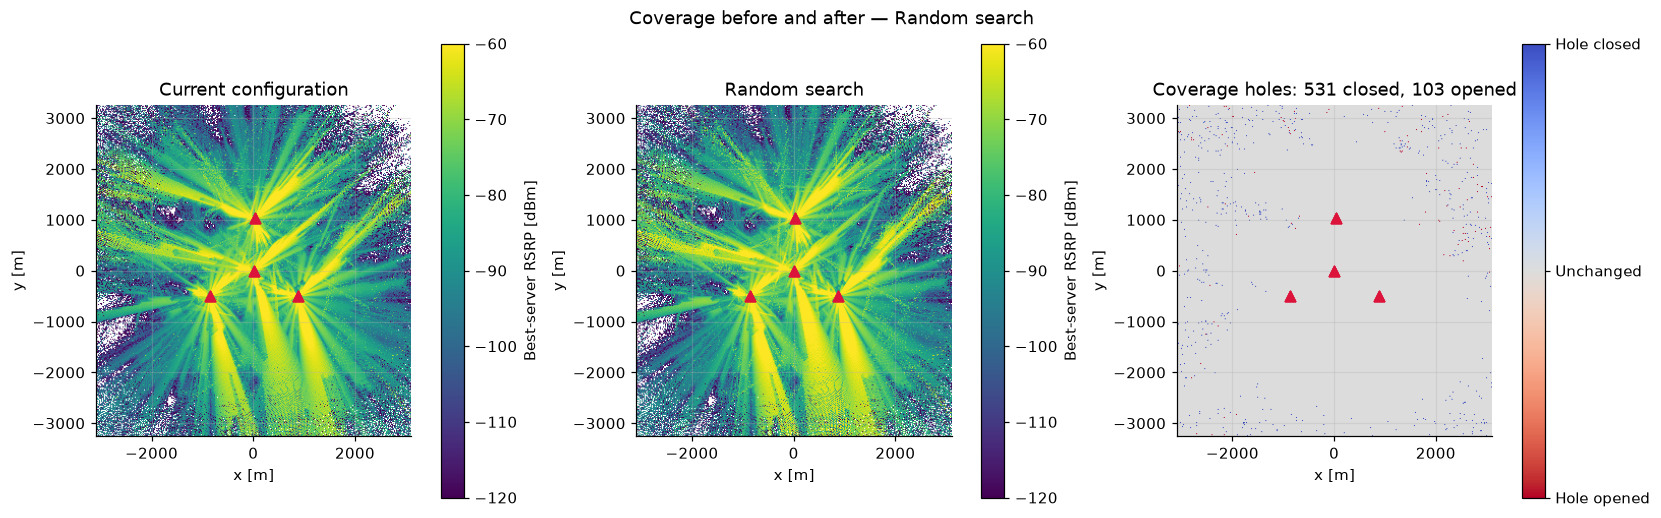

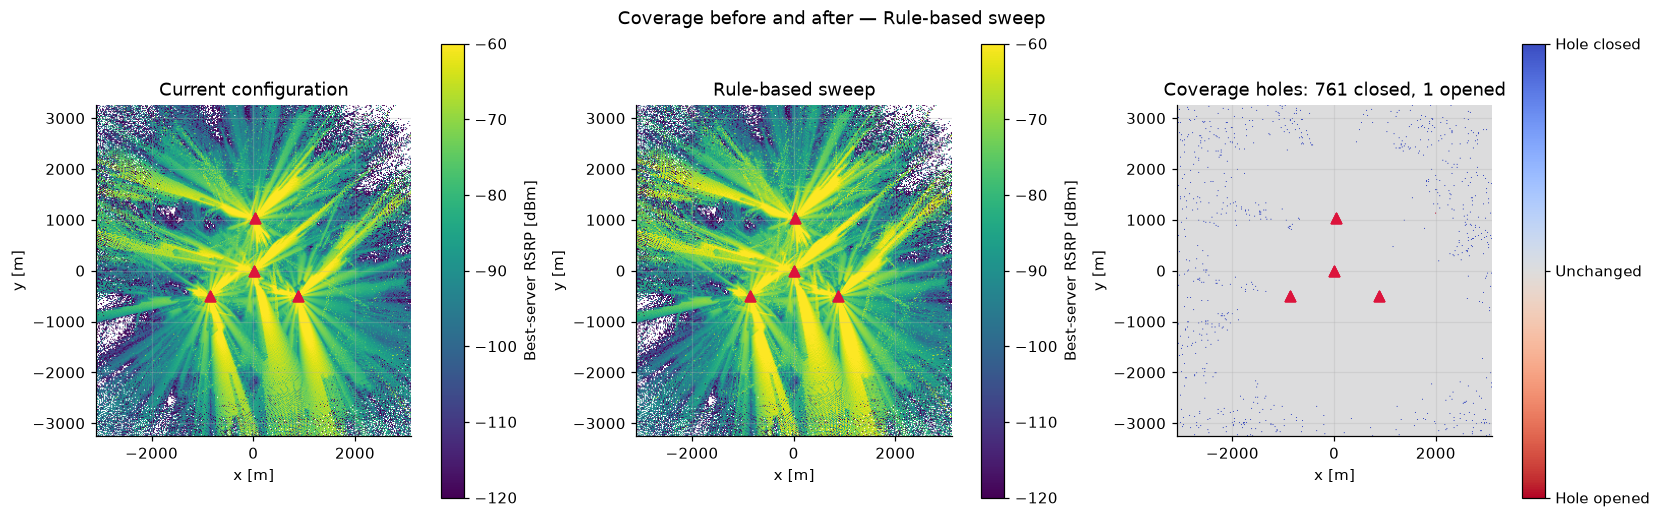

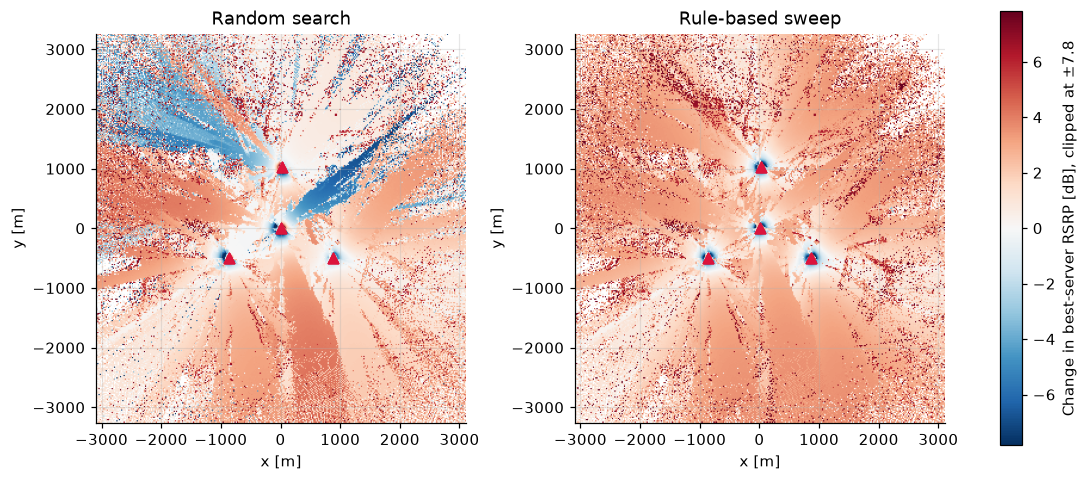

In [11]:
best_rsrp = {"incumbent": max_rsrp(baseline_rsrp)}
best_rsrp.update({method: max_rsrp(best[method].radio_map["rsrp_dbm"].astype(float)) for method in METHODS})

for method in METHODS:
    figure = plots.coverage_maps(
        best_rsrp["incumbent"], best_rsrp[method], baseline, cfg, cells=cells, name=method
    )
    save_fig(figure, f"coverage_before_after_{method}")
    plt.show()

# No path in either map makes the change undefined; it stays blank.
with np.errstate(invalid="ignore"):
    change = {label(m): best_rsrp[m] - best_rsrp["incumbent"] for m in METHODS}
figure = plots.map_row(
    change, baseline, colorbar_label="Change in best-server RSRP [dB]", symmetric=True, cells=cells
)
save_fig(figure, "rsrp_change_maps")
plt.show()

Regions worth inspecting: the cell edges between the three corner nodes and the centre node, the tiles that opened or
closed a hole, and heavily overlapped areas near the masts.

**Observations.** Both baselines raise best-server RSRP almost everywhere, and the sweep does it most evenly: it
improves 97.7 % of reached tiles by a median of 2.8 dB, closing 761 hole tiles while opening 1. Random search is the
weaker and noisier of the two - 80.6 % of tiles improve, median +1.5 dB, 531 holes closed and 103 opened - because a
single Sobol draw uptilts some cells far more than their neighbours and trades one area against another. Both differ
from the per-band objective's earlier band-collapsed form, under which the sweep downtilted 700 MHz; with each band
now carrying its own coverage term, every band is uptilted instead.

## 12. KPI-Level Analysis

Coverage classes by area and by demand, overlap, and which band serves the UEs. Demand is the incumbent's, for every
configuration, so the weights do not move. The project has no band-priority score; the serving-band mix is read
against the preference order `kpi.capacity.band_preference` instead.

,Coverage class,Current configuration: Share of area,Current configuration: Share of demand,Random search: Share of area,Random search: Share of demand,Rule-based sweep: Share of area,Rule-based sweep: Share of demand
0,hole,0.1125,0.000,0.1083,0.0027,0.105,0.0000
1,weak,0.3069,0.836,0.2864,0.7967,0.259,0.7703
2,good,0.5806,0.164,0.6054,0.2006,0.636,0.2297


,Configuration,Co-band overlap rate,Mean overlapping neighbours
0,Current configuration,0.3164,0.9625
1,Random search,0.3254,1.0303
2,Rule-based sweep,0.3193,1.1685


Band preference, most preferred first: 2600 MHz, 1800 MHz, 700 MHz


,Configuration,UE reports,Share not served,"Served SINR, 10th percentile [dB]","Served SINR, median [dB]","PRBs per served UE, median",Share served on 2600 MHz,Share served on 1800 MHz,Share served on 700 MHz
0,Current configuration,10087.0,0.4735,-0.3751,5.1257,53.1831,0.3408,0.1050,0.0807
1,Random search,10087.0,0.4118,0.2418,7.7253,39.8052,0.4506,0.0715,0.0661
2,Rule-based sweep,10087.0,0.4033,0.3796,7.7587,39.6705,0.4601,0.0659,0.0707


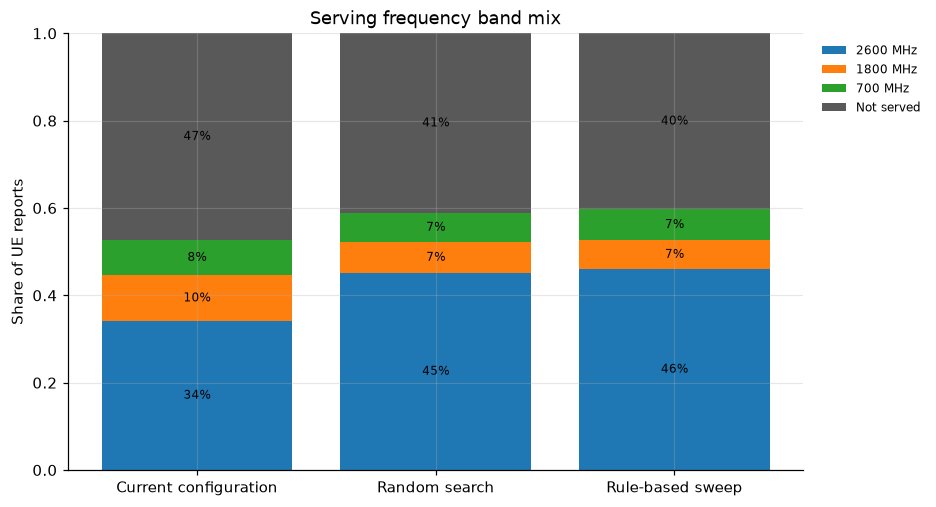

,Configuration,Band,Coverage hole rate,Co-band overlap rate,Overlap neighbours per covered tile,Weak coverage rate,"Cell-edge RSRP, p05 [dBm]","Median RSRP, p50 [dBm]","Cell-edge SINR, p05 [dB]","Median SINR, p50 [dB]",Served UE rate,Peak PRB utilisation,Cell load imbalance (CoV)
0,Current configuration,All bands,0.1125,0.3164,0.9625,0.3069,-108.5644,-84.1068,-5.8729,8.4932,0.5265,0.7999,0.9098
1,Current configuration,2600 MHz,0.2884,0.2010,0.3703,0.5124,-115.4094,-98.0890,-17.5911,-1.6299,0.3408,0.7999,0.6775
2,Current configuration,1800 MHz,0.2350,0.2067,0.3564,0.4171,-112.4538,-91.7208,-11.6703,4.1494,0.1050,0.7994,0.6074
3,Current configuration,700 MHz,0.1381,0.2396,0.3691,0.2945,-108.5333,-83.9182,-5.2264,8.3972,0.0807,0.7991,0.9986
4,Random search,All bands,0.1083,0.3254,1.0303,0.2864,-107.9820,-82.7177,-5.5418,9.2144,0.5882,0.7998,1.0092
5,Random search,2600 MHz,0.2587,0.1908,0.3972,0.4077,-113.9217,-91.9628,-16.1259,2.5799,0.4506,0.7998,0.5835
6,Random search,1800 MHz,0.2260,0.1952,0.3442,0.3546,-111.7681,-88.4004,-11.0177,6.1660,0.0715,0.7997,0.9939
7,Random search,700 MHz,0.1359,0.2422,0.4142,0.2831,-108.2549,-82.9697,-5.1376,8.6310,0.0661,0.7988,1.1114
8,Rule-based sweep,All bands,0.1050,0.3193,1.1685,0.2590,-107.1492,-81.1359,-4.9659,9.8424,0.5967,0.7999,0.9872
9,Rule-based sweep,2600 MHz,0.2534,0.1934,0.4171,0.3875,-113.4268,-90.7613,-15.6178,3.3646,0.4601,0.7999,0.5600


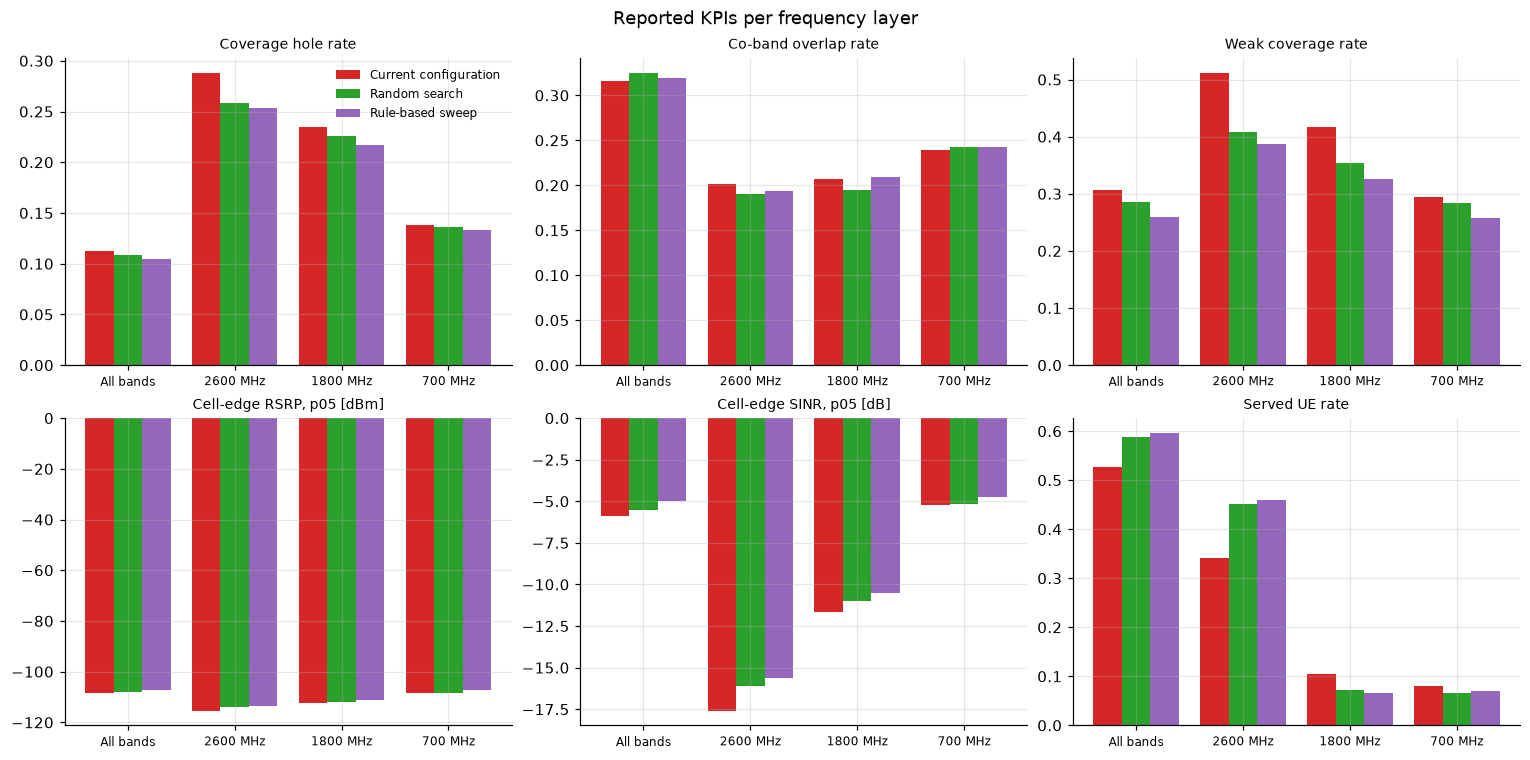

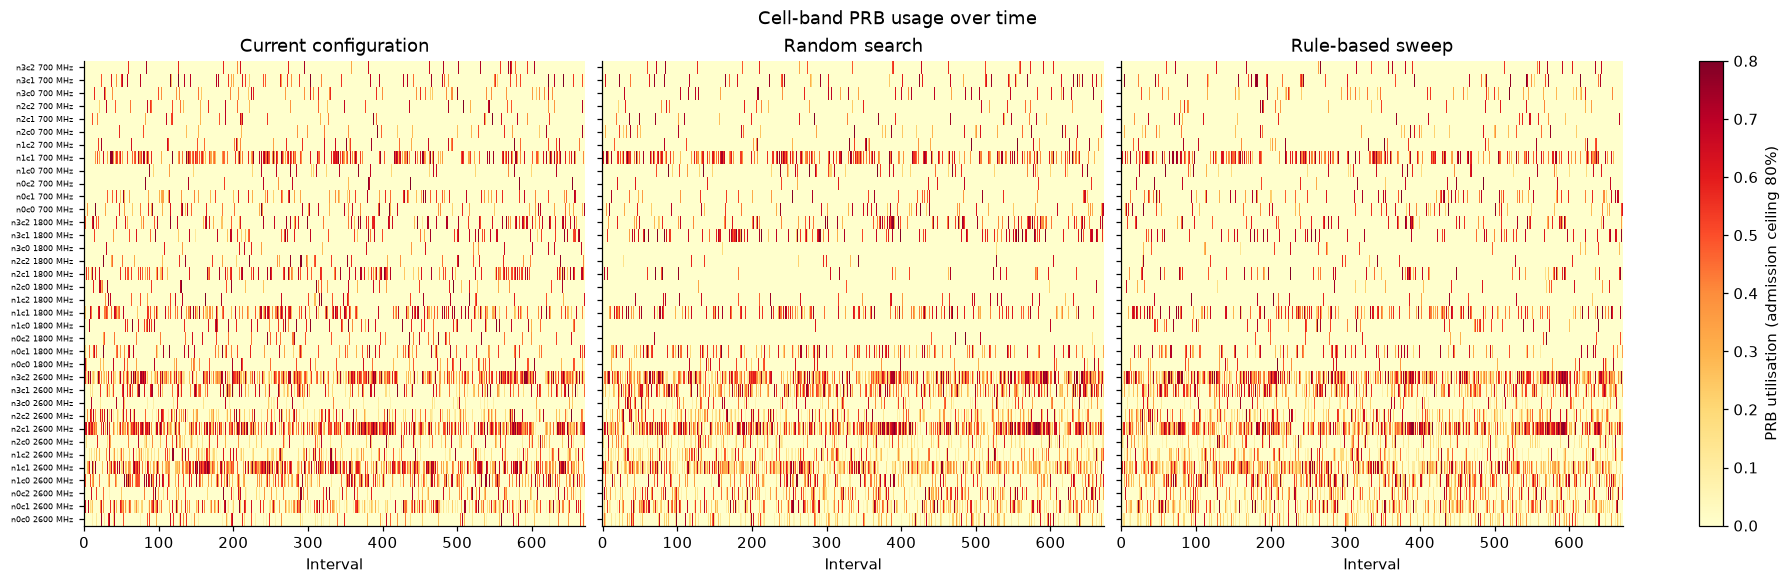

peak utilisation over every cell-band and interval: 80.0% (admission ceiling 80%)


In [12]:
configurations = {"incumbent": compare.configuration(baseline, ue, cfg)}
configurations.update({m: compare.configuration(best[m].radio_map, ue, cfg) for m in METHODS})
demand = configurations["incumbent"].demand

coverage = compare.coverage_comparison(
    {name: maps.coverage_table(c.rsrp, demand, cfg) for name, c in configurations.items()}
)
coverage.columns = ["coverage"] + [
    f"{label(key)}: {label(f'{share}_share')}"
    for key, share in (column.rsplit("_", 1) for column in coverage.columns[1:])
]
coverage = readable(coverage)
save_table(coverage, "coverage_by_area_and_demand")
display(coverage)

overlap = pd.DataFrame(
    {
        "configuration": list(configurations),
        "overlap_rate": [runs[0].incumbent_kpi.overlap_rate]
        + [best[m].best_kpi.overlap_rate for m in METHODS],
        "Mean overlapping neighbours": [mean_overlap_neighbors(c.rsrp) for c in configurations.values()],
    }
)
overlap = readable(overlap)
save_table(overlap, "overlap")
display(overlap)

band_labels = [str(band) for band in baseline["band_label"]]
print("Band preference, most preferred first:", ", ".join(label(b) for b in cfg.kpi.capacity.band_preference))
service = {name: compare.service_summary(c.served, band_labels) for name, c in configurations.items()}
service_table = readable(pd.DataFrame(service).T.rename_axis("configuration").reset_index())
save_table(service_table, "ue_service_summary")
display(service_table)
figure = plots.band_share_bars(service, band_labels)
save_fig(figure, "serving_band_mix")
plt.show()

tx_names = [str(name) for name in baseline["tx_name"]]
max_prb = CapacitySpec.from_config(cfg, band_labels, len(tx_names)).max_prb

# Every reported KPI, over all bands and per band, through the same functions:
# a band row is the definition given one band's layers, nothing new.
per_band = compare.band_kpis(configurations, band_labels, cfg)
save_table(readable(per_band), "band_kpis")
display(readable(per_band))
figure = plots.band_kpi_panels(
    per_band,
    ("hole_rate", "overlap_rate", "weak_rate", "rsrp_p05_dbm", "sinr_p05_db", "served_rate"),
)
save_fig(figure, "band_kpis")
plt.show()

# The series prb_utilisation_max and load_imbalance reduce. The admission
# ceiling bounds every cell in it, so a band running at the ceiling is a cell
# that refused traffic, not one that overloaded.
ceiling = float(cfg.kpi.capacity.max_admission_utilisation)
usage = compare.prb_usage_by_time(configurations, band_labels, tx_names, max_prb)
save_table(readable(usage), "prb_usage_by_time")
figure = plots.prb_usage_heatmaps(usage, ceiling)
save_fig(figure, "prb_usage")
plt.show()
print(f"peak utilisation over every cell-band and interval: {usage['utilisation'].max():.1%} "
      f"(admission ceiling {ceiling:.0%})")


### Coverage holes

Both baselines cut the hole rate by area: 0.1125 to 0.1050 for the sweep and 0.1083 for random search. The current
configuration has no demand on hole tiles; the sweep still moves none onto them, and random search moves 0.27 %.

### Coverage overlap

Neither baseline improves overlap. The sweep raises the overlap rate slightly (0.3164 to 0.3193) and the mean number
of overlapping neighbours over covered tiles from 0.963 to 1.168; random search raises the rate to 0.3254 and the mean
to 1.030, but leaves slightly fewer tiles with three or more neighbours (16.8 % against the incumbent's 17.6 %).

### Multi-band coordination

The share of UE reports served on 2600 MHz, the preferred band, grows from 34 % to 46 % for both methods, while the
1800 MHz share falls from 10 % to 7 % and 700 MHz from 8 % to 7 %. The served ratio rises with it, and served SINR
improves at the median (5.1 to about 7.7 dB) and at the 10th percentile (-0.4 to +0.2 dB and +0.4 dB).

### Weak coverage

Weak coverage falls by area for both methods (30.7 % to 25.9 % for the sweep and 28.6 % for random search), and the
share of demand on weak tiles falls with it (83.6 % to 77.0 % and 79.7 %). It is still where most of the demand sits.

## 13. Key Observations

- The current per-band tilts (12°, 10°, 8°) are all downtilted relative to what either baseline prefers: both uptilt
  every band, and both gain - +3.7 % on J for the sweep and +3.0 % for random search.
- A structured three-variable sweep beat unstructured 36-variable random search on J at a seventh of the ray-tracing
  cost (0.9 against 5.9 minutes). Random search found its best at evaluation 7 of 145 and never improved after that:
  its budget is spread too thinly over a 36-dimensional box to add anything beyond the initial design.
- The gains are broad rather than narrow. The sweep improves the hole rate, weak coverage, both RSRP percentiles,
  both SINR percentiles and the served rate at once, and closes 761 hole tiles while opening 1.
- What neither fixes is overlap or load: both raise the overlap rate and the neighbour count, both leave peak
  utilisation at the admission ceiling, and both make the load less even. Overlap is the gap a per-cell-band search
  can close and a per-band sweep structurally cannot.
- The sweep drives 1800 MHz to 0°, the bottom of its tilt box, so its result is partly set by the bounds.
- These are one seed on one scenario; notebook 04 reports intervals over seeds.

## 14. Baseline Limitations

- **Random search** does not model the objective landscape or reuse what earlier evaluations revealed; with 36
  variables, a fixed budget covers the box only sparsely. Its best point here is evaluation 7 of 145.
- **The rule-based sweep** cannot give cells on one band different tilts, so it cannot fix a local problem without
  moving every cell on that band, and coordinate descent stops at the first configuration no single band can improve.
  It is also the method that raises the overlap neighbour count most, for the same reason.
- Every candidate costs a full ray trace, so either method's result depends on the budget it was given.
- The winner is the best of many evaluations under one solver seed, so its score is biased upward (notebook 04,
  threats to validity).
- Neither method constrains how far an antenna moves; tilt change is reported, not penalised, and both move all 36
  cell-bands.

## 15. Baselines vs. the Proposed Method

| Property | Random search | Rule-based sweep | TuRBO (notebook 03b) |
| --- | --- | --- | --- |
| Search strategy | Sobol sampling over the box | Shared tilt per band, coordinate descent | Trust-region Bayesian optimization |
| Surrogate model | No | No | Gaussian process |
| Uses previous evaluations | No | Only the current best | Yes, to fit the model and move the trust region |
| High-dimensional search | Uniform coverage, thins with dimension | Collapses 36 variables to 3 | Local trust region around the best point |
| Simulations | `n_init + n_iter` | `n_band · n_steps · n_rounds` at most | `n_init + n_iter`, as random search |
| Best objective | Section 10 | Section 10 | Notebook 04 |

All three share the initial network state, simulator, scenario, constraints and objective; random search and TuRBO
also share the evaluation budget and the initial Sobol design. The comparison with confidence intervals over seeds is
in notebook 04.

## 16. Conclusion

The baselines set a reproducible reference for multi-band tilt optimization on this scenario. They show:

- the improvement a simple strategy reaches, led by the rule-based sweep (+2.6 % on J in 28 evaluations);
- how tilt drives the objective here: the current configuration is over-downtilted, and uptilting every band buys
  coverage, signal quality and served traffic together;
- the two measures that resist both baselines - overlap neighbours per covered tile and cell load imbalance;
- that unstructured search over the 36-dimensional tilt space is inefficient at this budget.

TuRBO (notebook 03b) has to beat the rule-based sweep, not just random search, to justify its cost; notebook 04
makes that comparison.